Title: Combine_and_add_smard.ipynb

Purpose: Combine all datasets and add the SMARD Data to the dataset

Author: Onno Nennecke on 09.06.2025 Modified: 23.02.2026

Input data: 

- Model output data
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/full_year/'

- SMARD data 
    - This file lies here: '/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv'
    - This file lies here: '/home/onennecke/SMARD_data/Realisierter_Stromverbrauch_201501010000_202505010000_Tag.csv'

Output data:

- Combined model output: model_output_all.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import scipy.ndimage as ndimage
import seaborn as sns
import os
import glob

In [2]:
#### path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/future_full_year/'


files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets.load()

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 193, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 ... -8.134 -9.41
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.636e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... 3.01 4.735
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... 38.66 48.7
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 ... -7.047 -8.388
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 ... -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 31.44 148.9
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 71.95 87.86
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 113.4 316.1
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 ... -1.32e+03
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 ... 1.32e+03

### Add SMARD Data

In [3]:
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))
ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 193, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 ... -8.134 -9.41
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.636e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... 3.01 4.735
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... 38.66 48.7
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 ... -7.047 -8.388
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 ... -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 31.44 148.9
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 71.95 87.86
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 113.4 316.1
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 ... -1.32e+03
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 ... 1.32e+03

#### Load SMARD data

In [4]:
SMARD_data_prod = pd.read_csv('/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')
SMARD_data_demand = pd.read_csv('/home/onennecke/SMARD_data/Realisierter_Stromverbrauch_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')

In [5]:

date = pd.to_datetime(SMARD_data_prod['Datum von'].astype(str).str.zfill(8), format='%d%m%Y')
demand_sm = SMARD_data_demand['Netzlast [MWh] Berechnete Auflösungen']
wind_off_prod = SMARD_data_prod['Wind Offshore [MWh] Berechnete Auflösungen']
wind_on_prod = SMARD_data_prod['Wind Onshore [MWh] Berechnete Auflösungen']
solar_prod = SMARD_data_prod['Photovoltaik [MWh] Berechnete Auflösungen']
total_prod = wind_off_prod + wind_on_prod + solar_prod
residual_load = demand_sm - total_prod

df = pd.DataFrame({
    'date': date,
    'demand_SMARD': demand_sm / 1000,  # Convert to GWh
    'wind_offshore_SMARD': wind_off_prod / 1000,  # Convert to GWh
    'wind_onshore_SMARD': wind_on_prod / 1000,  # Convert to GWh
    'solar_SMARD': solar_prod / 1000,  # Convert to GWh
    'total_production_SMARD': total_prod / 1000,  # Convert to GWh
    'residual_load_SMARD': residual_load / 1000,  # Convert to GWh
})
# Cut data to only inclued ONDJFM
# df = df[df['date'].dt.month.isin([1, 2, 3, 10, 11, 12])]
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2024-12-31')]
# Exclude 29th February in leap years
df = df[~((df['date'].dt.month == 2) & (df['date'].dt.day == 29))]
df

,date,demand_SMARD,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,total_production_SMARD,residual_load_SMARD
0,2015-01-01,1096.85275,12.50850,298.79175,17.08025,328.38050,768.47225
1,2015-01-02,1288.91475,10.32925,591.62075,7.75900,609.70900,679.20575
2,2015-01-03,1213.30950,12.11950,457.04350,7.23475,476.39775,736.91175
3,2015-01-04,1177.89600,11.53850,379.02950,19.98250,410.55050,767.34550
4,2015-01-05,1425.92750,7.74550,219.62350,26.52225,253.89125,1172.03625
...,...,...,...,...,...,...,...
3648,2024-12-27,1155.15125,2.94125,46.42200,61.20575,110.56900,1044.58225
3649,2024-12-28,1150.65975,22.34775,31.44225,61.08850,114.87850,1035.78125
3650,2024-12-29,1179.16200,97.29825,257.39450,39.71900,394.41175,784.75025
3651,2024-12-30,1278.28500,61.18675,534.34725,22.92750,618.46150,659.82350


In [6]:
# Get existing time coordinate
time = ts_datasets.coords['time']

# Example new data values (use real data in practice)
SMARD_data = {
    'temp': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'demand': (['ESM_run', 'time'], df['demand_SMARD'].values.reshape(1, -1)),
    'sfcWind': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'rsds': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'tas': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'tasmax': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'wind_off_prod': (['ESM_run', 'time'], df['wind_offshore_SMARD'].values.reshape(1, -1)),
    'wind_on_prod': (['ESM_run', 'time'], df['wind_onshore_SMARD'].values.reshape(1, -1)),
    'solar_prod': (['ESM_run', 'time'], df['solar_SMARD'].values.reshape(1, -1)),
    'total_prod': (['ESM_run', 'time'], df['total_production_SMARD'].values.reshape(1, -1)),
    'Netto': (['ESM_run', 'time'], np.full((1, len(time)), np.nan)),
    'Residual_load': (['ESM_run', 'time'], df['residual_load_SMARD'].values.reshape(1, -1))
}

# New coordinate values for the new ESM_run
SMARD_coords = {
    'ESM_run': ['SMARD_hist'],
    'run': (['ESM_run'], ['hist']),
    'ESM': (['ESM_run'], ['SMARD']),
    # 'old_time': (['ESM_run', 'time'], ts_datasets.coords['old_time'][0].values.reshape(1, -1))
}

# Fixed coords broadcasted from the original dataset
static_coords = {
    'time': time,
    'gridtype': ts_datasets.gridtype,
    'country': ts_datasets.country,
    'period': 'wwd',
    # 'winter_year': ts_datasets.winter_year,
    # 'day_of_winter': ts_datasets.day_of_winter,
    # 'winter_season': ts_datasets.winter_season,
}

# Combine all into a SMARD dataset
SMARD_ds = xr.Dataset(data_vars=SMARD_data, coords={**SMARD_coords, **static_coords})


### Combine both datasets

In [7]:
combined_ds = xr.concat([ts_datasets, SMARD_ds], dim='ESM_run')
combined_ds

<xarray.Dataset> Size: 68MB
Dimensions:        (ESM_run: 194, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 -2.722 ... nan nan
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... nan nan nan
    rsds           (ESM_run, time) float64 6MB 13.75 24.11 38.15 ... nan nan nan
    tas            (ESM_run, time) float64 6MB 2.114 -0.7924 -2.629 ... nan nan
    tasmax         (ESM_run, time) float64 6MB 4.033 0.7523 -0.9483 ... nan nan
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 61.19 69.34
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 534.3 529.0
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 618.5 647.4
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 -907.2 ... nan nan
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 907.2 ... 659.8 556.8

### Save the data

In [8]:
combined_ds['ESM'].values

array(['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', '

In [9]:
encoding = {}

all_vars = {**combined_ds.data_vars, **combined_ds.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"S{maxlen}"}
encoding

{'gridtype': {'dtype': 'S6'},
 'ESM': {'dtype': 'S13'},
 'run': {'dtype': 'S12'},
 'ESM_run': {'dtype': 'S23'},
 'period': {'dtype': 'S4'}}

In [10]:
encoding = {}

all_vars = {**combined_ds.data_vars, **combined_ds.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'gridtype': {'dtype': 'U6'},
 'ESM': {'dtype': 'U13'},
 'run': {'dtype': 'U12'},
 'ESM_run': {'dtype': 'U23'},
 'period': {'dtype': 'U4'}}

In [11]:
# Save dataset
combined_ds.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc', encoding=encoding)
# combined_ds.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc')

In [12]:
# Load the saved dataset to verify
ts_datasets = xr.load_dataset('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc')
ts_datasets

<xarray.Dataset> Size: 60MB
Dimensions:        (ESM_run: 194, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 -2.722 ... nan nan
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... nan nan nan
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... nan nan nan
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 -2.629 ... nan nan
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 -0.9483 ... nan nan
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 61.19 69.34
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 534.3 529.0
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 618.5 647.4
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 -907.2 ... nan nan
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 907.2 ... 659.8 556.8

In [14]:
ts_datasets['ESM'].values

array(['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', '

### Plotting

In [ ]:
# Plot timeseries with ts_datasets first year
ts_datasets_one = ts_datasets.isel(ESM_run=0)

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 91
b = 91 +181
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = ts_datasets_one['time'][a:b]
demand = ts_datasets_one['demand'][a:b]
wind_off = ts_datasets_one['wind_off_prod'][a:b]
wind_on = ts_datasets_one['wind_on_prod'][a:b]
solar = ts_datasets_one['solar_prod'][a:b]
total_prod = ts_datasets_one['total_prod'][a:b]
Residual_load = ts_datasets_one['Residual_load'][a:b]


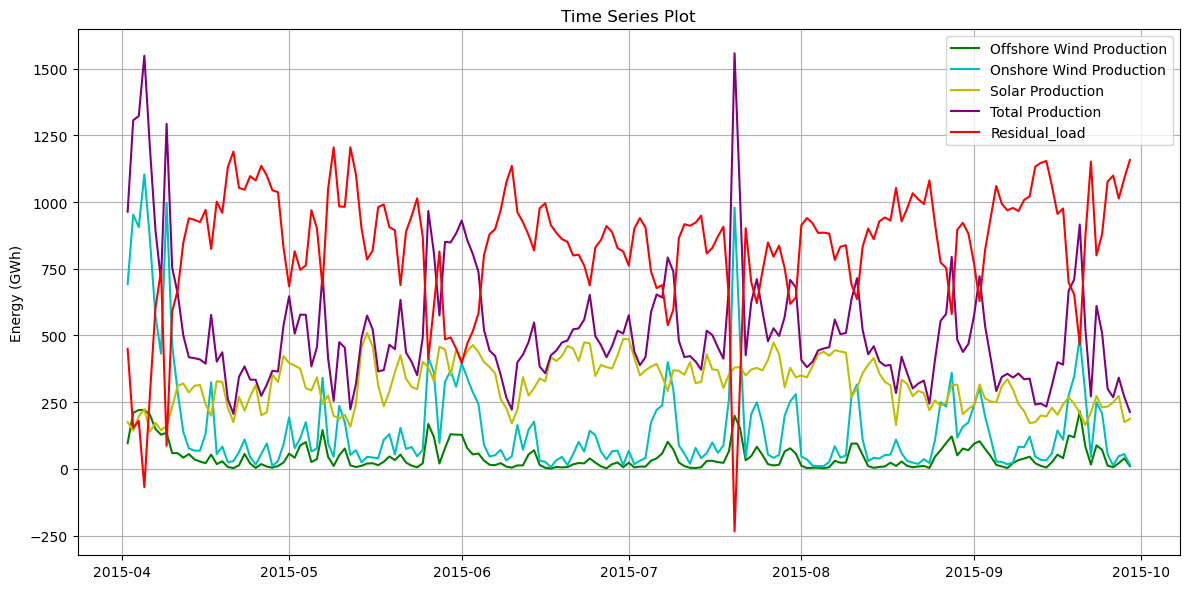

In [ ]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')

ax.plot(time, wind_on, label='Onshore Wind Production', color='c')

ax.plot(time, solar, label='Solar Production', color='y')

ax.plot(time, total_prod, label='Total Production', color='purple')

ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()